## 1 — Importar bibliotecas

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2 — Carregar os dados

In [ ]:
url = "https://raw.githubusercontent.com/rochaapdrr/TelecomX-Churn-Analysis/main/data/raw/telecomx_tratado.csv"

df = pd.read_csv(url)

df.head()

,ID_Cliente,Evasao,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefonico,Multiplas_Linhas,Provedor_Internet,...,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Online,Forma_Pagamento,Faturamento_Mensal,Faturamento_Total,Contas_Diarias,Evasao_Binaria,Quantidade_Servicos
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19,0,5
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00,0,4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46,1,3
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27,1,6
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80,1,4


## 3 — Ver estrutura dos dados

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_Cliente            7043 non-null   object 
 1   Evasao                7043 non-null   object 
 2   Genero                7043 non-null   object 
 3   Idoso                 7043 non-null   int64  
 4   Parceiro              7043 non-null   object 
 5   Dependentes           7043 non-null   object 
 6   Meses_Contrato        7043 non-null   int64  
 7   Servico_Telefonico    7043 non-null   object 
 8   Multiplas_Linhas      7043 non-null   object 
 9   Provedor_Internet     7043 non-null   object 
 10  Seguranca_Online      7043 non-null   object 
 11  Backup_Online         7043 non-null   object 
 12  Protecao_Dispositivo  7043 non-null   object 
 13  Suporte_Tecnico       7043 non-null   object 
 14  Streaming_TV          7043 non-null   object 
 15  Streaming_Filmes     

## 4 — Preparação dos dados

In [ ]:
# remover coluna duplicada de churn
df = df.drop(columns=["Evasao"], errors="ignore")

# separar variável alvo
y = df["Evasao_Binaria"]

# remover target das features
X = df.drop(columns=["Evasao_Binaria"])

# transformar variáveis categóricas em numéricas
X = pd.get_dummies(X, drop_first=True)

print("Formato final do dataset:", X.shape)

Formato final do dataset: (7043, 7074)


In [ ]:
#criando uma variavel dados_tratados_ml
dados_tratados_ml = X.copy()
dados_tratados_ml.to_csv('dados_tratados_ml.csv')

## 5 — Dividir treino e teste

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 6 — Escalar dados

(necessário para regressão logística)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7 — Modelo 1: Regressão Logística

In [ ]:
modelo_log = LogisticRegression(max_iter=1000)

modelo_log.fit(X_train_scaled, y_train)

y_pred_log = modelo_log.predict(X_test_scaled)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.79      0.96      0.86      1036
           1       0.70      0.29      0.41       373

    accuracy                           0.78      1409
   macro avg       0.74      0.62      0.64      1409
weighted avg       0.76      0.78      0.74      1409



## 8 — Matriz de confusão

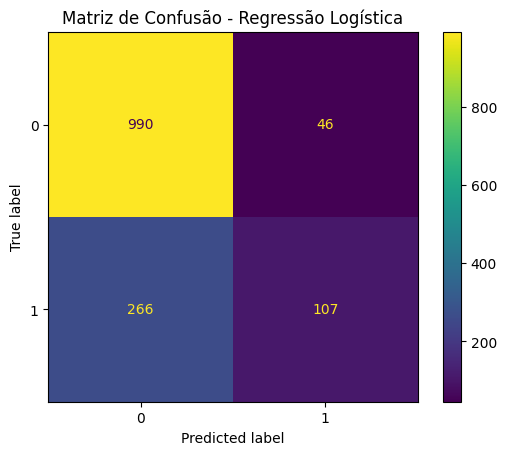

In [ ]:
fig, ax = plt.subplots()

cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)

plt.title("Matriz de Confusão - Regressão Logística")

fig.savefig("confusion_matrix.png", bbox_inches="tight")

plt.show()

## 9 — Modelo 2: Random Forest

In [ ]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1036
           1       0.68      0.45      0.54       373

    accuracy                           0.80      1409
   macro avg       0.75      0.68      0.70      1409
weighted avg       0.78      0.80      0.78      1409



## 10 — Importância das variáveis

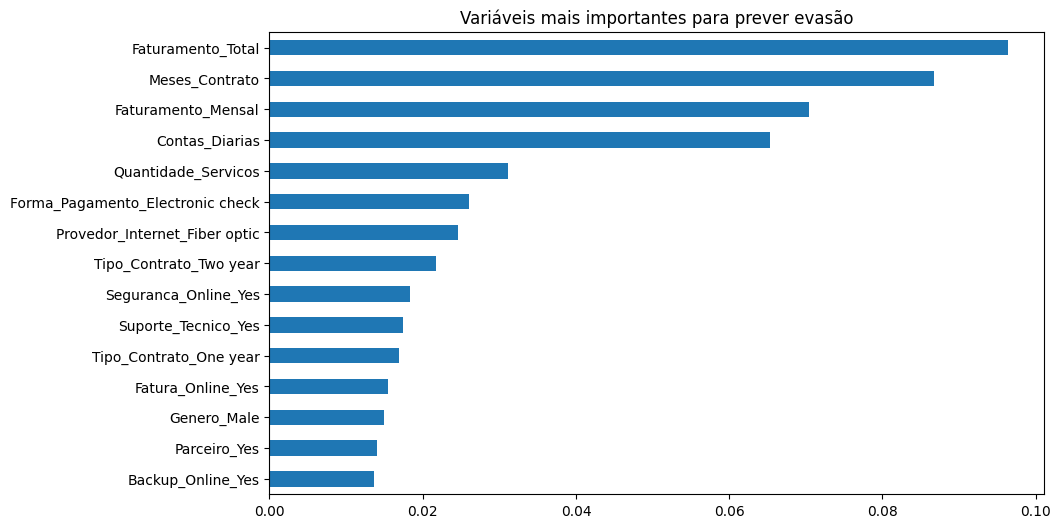

In [ ]:
importancias = modelo_rf.feature_importances_

feat_importance = pd.Series(importancias, index=X.columns)

feat_importance.sort_values().tail(15).plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Variáveis mais importantes para prever evasão")

plt.show()

In [ ]:
fig.savefig("feature_importance.png", bbox_inches="tight")

plt.show()

## 11 — Comparação de modelos

In [ ]:
from sklearn.metrics import accuracy_score

acc_log = accuracy_score(y_test, y_pred_log)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy Regressão Logística:", acc_log)
print("Accuracy Random Forest:", acc_rf)

Accuracy Regressão Logística: 0.7785663591199432
Accuracy Random Forest: 0.7977288857345636


## Conclusões

### Principais fatores associados ao churn

- Clientes com contratos mensais possuem maior risco

- Clientes com pouco tempo de permanência cancelam mais

- Serviços adicionais reduzem o churn

- Clientes com cobranças mais altas apresentam maior evasão